In [9]:
import numpy as np
import matplotlib.pyplot as plt


# General Decay Chains

Description of the problem: We have a parent nucleus that decays into another radioactive nucleus (the daughter nucleus). If the daughter is still radioactive, this leads to a decay chain that continues until a stable isotope is reached.

$N_1 \rightarrow N_2 \rightarrow N_3 \rightarrow \dots \rightarrow N_n$

System of Differential Equations

$$\frac{dN_i}{dt} = \lambda_{i-1} N_{i-1} - \lambda_i N_i$$

We can write the system as:$$\frac{d\vec{N}}{dt} = \mathbf{A}\vec{N}$$

$\vec{N}$ is the vector of abundances $\begin{bmatrix} N_1 & N_2 & N_3 & \dots & N_n \end{bmatrix}^T$, and $\mathbf{A}$ is a lower-bidiagonal matrix of the decay constants:$$\mathbf{A} = \begin{bmatrix} 
-\lambda_1 & 0 & 0 & \dots & 0 \\
\lambda_1 & -\lambda_2 & 0 & \dots & 0 \\
0 & \lambda_2 & -\lambda_3 & \dots & 0 \\
\vdots & \vdots & \ddots & \ddots & \vdots \\
0 & 0 & \dots & \lambda_{n-1} & -\lambda_n 
\end{bmatrix}$$

This matrix contains only decay constants ($\lambda$). It is used when you want to solve the differential equations numerically step-by-step.

To express the integrated solution ($N(t)$) we should determining the Coefficients from eq. (2.18) of our text book.

$$\vec{N}(t) = \mathbf{M}_{coef} \vec{E}(t)$$ $$\mathbf{M}_{coef} = \begin{bmatrix} 
a_{11} & 0 & 0 & 0 \\
a_{21} & a_{22} & 0 & 0 \\
a_{31} & a_{32} & a_{33} & 0 \\
a_{41} & a_{42} & a_{43} & a_{44}
\end{bmatrix}$$

eq. (2.18)

$$a_{k,i} = \frac{\lambda_1 \lambda_2 \dots \lambda_{k-1}}{(\lambda_1 - \lambda_i)(\lambda_2 - \lambda_i)\dots(\lambda_k - \lambda_i)} a_{11}$$

In [10]:
lamda = [0, 0.5, 0.2, 0.1]  
num_members = 3             # N_1, N_2, N_3
N1_0 = 100.0                # Initial condition: a_11 = N_1(t=0)

# Initialize a 2D matrix for a_ki coefficients filled with zeros
a = np.zeros((num_members + 1, num_members + 1))

# Equation (2.15): a_11 = N_1(0)
a[1, 1] = N1_0

# Calculate the rest of the a_ki coefficients using Equation (2.18)
for k in range(2, num_members + 1):
    for i in range(1, k + 1):
        
        if i == k:
            # Equation (2.15): The sum of a_ki for i=1 to k must equal 0
            # So, a_kk = - sum(a_ki) for i from 1 to k-1
            a[k, k] = -np.sum(a[k, 1:k])
        else:
            # Equation (2.18): Calculate numerator and denominator
            # Numerator: lambda_1 * lambda_2 * ... * lambda_{k-1}
            numerator = np.prod(lamda[1:k]) * a[1, 1]
            
            # Denominator: (lambda_1 - lambda_i) * ... * (lambda_k - lambda_i) [excluding j=i]
            denominator = 1.0
            for j in range(1, k + 1):
                if j != i:
                    denominator *= (lamda[j] - lamda[i])
            
            a[k, i] = numerator / denominator

# Display the calculated coefficient matrix (ignoring the 0th row/column)
print("Calculated a_ki coefficients:")
print(a[1:, 1:])

Calculated a_ki coefficients:
[[ 100.            0.            0.        ]
 [-166.66666667  166.66666667    0.        ]
 [  83.33333333 -333.33333333  250.        ]]


$$\begin{bmatrix} N_1(t) \\ N_2(t) \\ N_3(t) \end{bmatrix} = \begin{bmatrix} a_{11} & 0 & 0 \\ a_{21} & a_{22} & 0 \\ a_{31} & a_{32} & a_{33} \end{bmatrix} \begin{bmatrix} e^{-\lambda_1 t} \\ e^{-\lambda_2 t} \\ e^{-\lambda_3 t} \end{bmatrix}$$

Row 1: $N_1(t) = a_{11}e^{-\lambda_1 t} + 0 + 0$

Row 2: $N_2(t) = a_{21}e^{-\lambda_1 t} + a_{22}e^{-\lambda_2 t} + 0$

Row 3: $N_3(t) = a_{31}e^{-\lambda_1 t} + a_{32}e^{-\lambda_2 t} + a_{33}e^{-\lambda_3 t}$

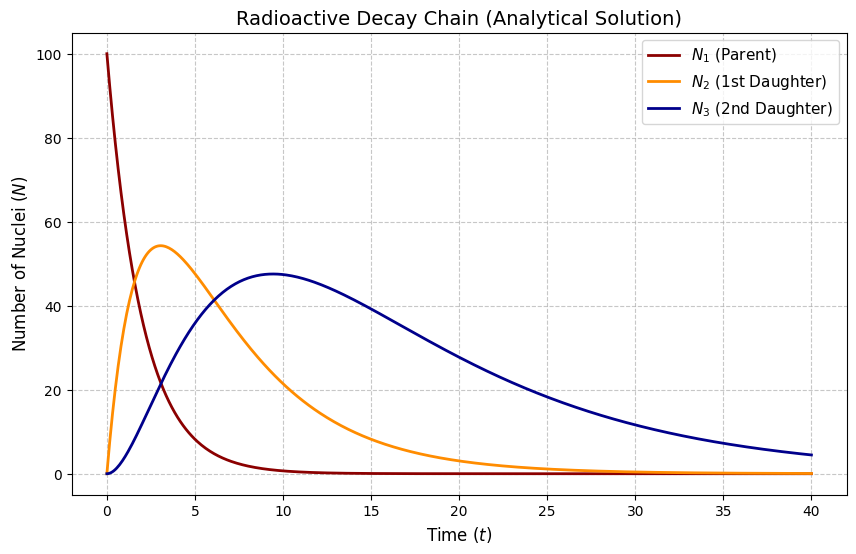

In [11]:
# time grid for plotting
t = np.linspace(0, 40, 500)  # Simulate from t=0 to t=40 seconds/hours

# We will store the populations N over time t in a dictionary or list
N_t = {}

for k in range(1, num_members + 1):
    N_t[k] = np.zeros_like(t)
    # Sum up the components: a_ki * exp(-lambda_i * t)
    for i in range(1, k + 1):
        N_t[k] += a[k, i] * np.exp(-lamda[i] * t)

# PLOTTING THE RESULTS 
plt.figure(figsize=(10, 6))

plt.plot(t, N_t[1], label=r"$N_1$ (Parent)", color="darkred", lw=2)
plt.plot(t, N_t[2], label=r"$N_2$ (1st Daughter)", color="darkorange", lw=2)
plt.plot(t, N_t[3], label=r"$N_3$ (2nd Daughter)", color="darkblue", lw=2)
plt.title("Radioactive Decay Chain (Analytical Solution)", fontsize=14)
plt.xlabel("Time ($t$)", fontsize=12)
plt.ylabel("Number of Nuclei ($N$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=11)

# Show the plot
plt.show()

The parent nucleus population ($N_1$, dark red curve) decreases monotonically over time, starting from its maximum value of $100$ at $t = 0$. Because it sits at the absolute top of the chain, its rate of change is governed strictly by its own destruction.

$$\frac{dN_i}{dt} = \text{Creation Rate} - \text{Destruction Rate} = \lambda_{i-1} N_{i-1} - \lambda_i N_i$$

The first daughter nucleus ($N_2$) starts at $N_2 = 0$. Because the parent population is at its maximum ($N_1 = 100$), it instantly ignites a high creation rate for $N_2$. This causes the rapid initial increase we see on the plot. As $N_2$ accumulates, its own destruction rate grows while the parent source depletes. Once the creation and destruction rates balance, $N_2$ hits its maximum "top." Immediately after, destruction takes over, driving the curve downward.Following the exact same physical process, $N_3$ cannot begin its growth until there are enough $N_2$ atoms to ignite its own creation mechanism. This dependence creates a distinct time lag, shifting the $N_3$ peak later in time relative to $N_2$. Furthermore, because the system does not end at a stable isotope in this general test case, $N_3$ also undergoes a slower, final decrease as the available matter continuously flows down and out of the simulated chain.

# Radium A decay

Many radioactive chains take billions of years (like Uranium-238) or milliseconds to decay. The Radium A series has half-lives of 3.1 minutes, 26.8 minutes, and 19.9 minutes. This allows us to simulate and plot the entire dynamic lifecycle of a decay chain over a clean, realistic time grid (0 to 150 minutes)

$$\text{RaA} \rightarrow \text{RaB} \rightarrow \text{RaC} \rightarrow \text{RaD}$$

$\text{RaA}$ ($^{218}\text{Po}$ - Polonium): $T_{1/2} = 3.10 \text{ minutes}$ (Decays via $\alpha$)

$\text{RaB}$ ($^{214}\text{Pb}$ - Lead): $T_{1/2} = 26.8 \text{ minutes}$ (Decays via $\beta^-$)

$\text{RaC}$ ($^{214}\text{Bi}$ - Bismuth): $T_{1/2} = 19.9 \text{ minutes}$ (Decays via $\beta^-$)

$\text{RaD}$ ($^{210}\text{Pb}$ - Lead): $T_{1/2} = 22.3 \text{ years}$

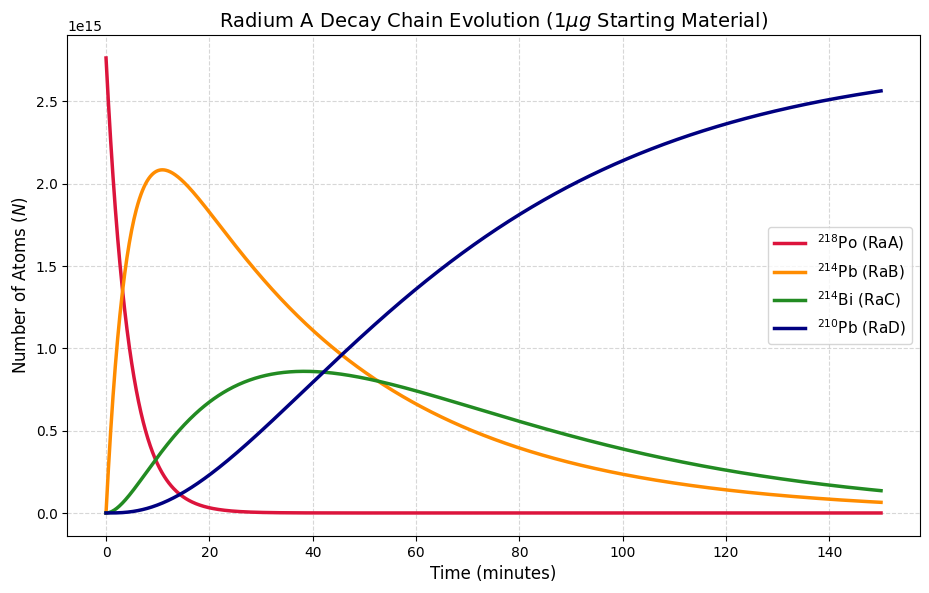

In [13]:
N_A = 6.022e23  # Avogadro's number
molar_mass_parent = 218.0  # g/mol for 218Po
initial_mass = 1e-6  # 1 microgram

# Calculate actual starting atom count for N_1
N1_0 = (initial_mass / molar_mass_parent) * N_A

# THE ISOTOPE DECAY CHAIN DATA 
num_members = 4

# Half-lives converted cleanly to seconds
half_lives = [
    3.10 * 60,  # Po-218 (RaA)
    26.8 * 60,  # Pb-214 (RaB)
    19.9 * 60,  # Bi-214 (RaC)
    22.3 * 365.25 * 24 * 3600,  # Pb-210 (RaD) -> Very long!
]

# Calculate decay constants: lambda = ln(2) / T_1/2
# Pad with a 0 at index 0 for 1-based indexing alignment with textbook
lamda = [0] + [np.log(2) / T for T in half_lives]

# ANALYTICAL BATEMAN SOLVER MATRIX 
a = np.zeros((num_members + 1, num_members + 1))
a[1, 1] = N1_0

for k in range(2, num_members + 1):
    for i in range(1, k + 1):
        if i == k:
            a[k, k] = -np.sum(a[k, 1:k])
        else:
            numerator = np.prod(lamda[1:k]) * a[1, 1]
            denominator = 1.0
            for j in range(1, k + 1):
                if j != i:
                    denominator *= (lamda[j] - lamda[i])
            a[k, i] = numerator / denominator

# TIME GRID (0 to 150 minutes, converted to seconds)
t = np.linspace(0, 150 * 60, 1000)

# Evaluate N_k(t) functions
N_t = {}
for k in range(1, num_members + 1):
    N_t[k] = np.zeros_like(t)
    for i in range(1, k + 1):
        N_t[k] += a[k, i] * np.exp(-lamda[i] * t)

# PLOTTING THE REAL-WORLD CURVES 
plt.figure(figsize=(11, 6.5))
t_minutes = t / 60  # X-axis in minutes for intuitive reading

plt.plot(
    t_minutes, N_t[1], label=r"$^{218}$Po (RaA)", color="crimson", lw=2.5
)
plt.plot(
    t_minutes, N_t[2], label=r"$^{214}$Pb (RaB)", color="darkorange", lw=2.5
)
plt.plot(
    t_minutes, N_t[3], label=r"$^{214}$Bi (RaC)", color="forestgreen", lw=2.5
)
plt.plot(
    t_minutes, N_t[4], label=r"$^{210}$Pb (RaD)", color="navy", lw=2.5
)
plt.title("Radium A Decay Chain Evolution ($1\mu g$ Starting Material)", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Number of Atoms ($N$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="right")
plt.gca().ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.show()

The defining feature of this realistic simulation is the behavior of the fourth member, $^{210}\text{Pb}$ (dark blue curve). Unlike the intermediate daughters, this isotope does not peak and decline. Because its half-life is exceptionally long ($22.3\text{ years}$), its decay constant is effectively zero ($\lambda_4 \approx 0$) on this $150\text{-minute}$ timescale. It acts as a permanent mathematical sink, meaning it only accumulates matter and never destroys it, satisfying the stable end-product condition:$$\frac{dN_4}{dt} = \lambda_3 N_3$$

The growth of $^{210}\text{Pb}$ starts out very slowly at the beginning. This is because it sits at the bottom of the chain. It cannot be created until $^{218}\text{Po}$ decays into $^{214}\text{Pb}$, which must then decay into $^{214}\text{Bi}$. The inflection point—where the blue curve transitions from growing slowly to increasing rapidly—occurs precisely after the intermediate parents ($N_2$ and $N_3$) have reached their respective peaks. Once the reservoir of $^{214}\text{Bi}$ (green curve) is fully charged, the creation rate of $^{210}\text{Pb}$ hits its maximum velocity.

If we look at the asymptotic behavior as $t \to 150\text{ minutes}$, the intermediate curves ($\text{RaA, RaB, RaC}$) are all draining toward zero, while the $\text{RaD}$ curve approaches a value near $2.7 \times 10^{15}\text{ atoms}$. This matches the initial starting atom count $N_1(0)$. This provides an excellent computational validation of the conservation of nucleon number :

$$\sum_{i=1}^{4} N_i(t) = N_1(0) = \text{Constant}$$

# Activity A(t) :  rate of decay

By definition, activity is the rate of decay, which is proportional to the number of radioactive nuclei present at that moment:$$A(t) = \lambda N(t)$$

Where $\lambda$ is the decay constant ($\lambda = \frac{\ln(2)}{T_{1/2}}$).

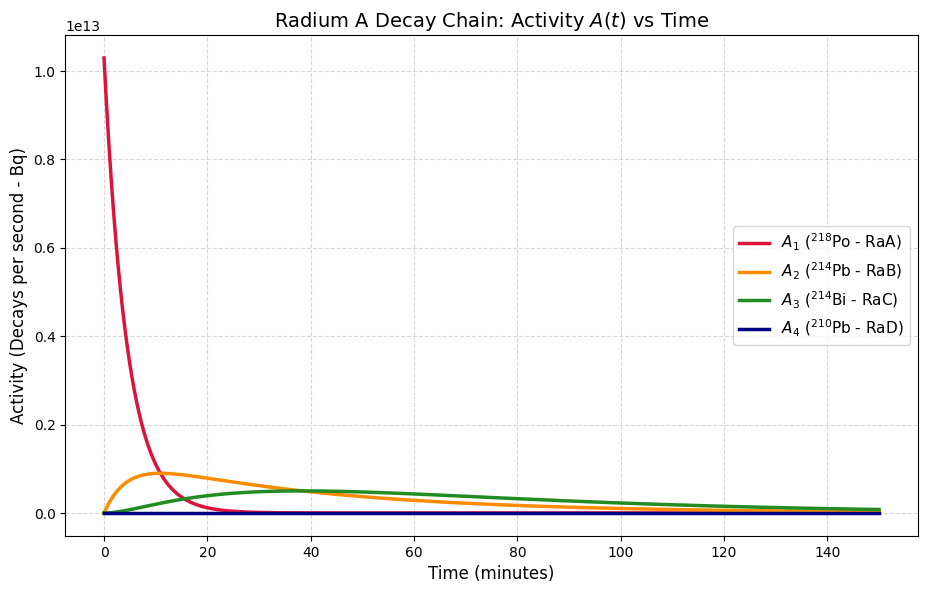

In [15]:
# 1. Compute the activities directly from the existing N_t and lamda
A_t = {}
for k in range(1, num_members + 1):
    A_t[k] = lamda[k] * N_t[k]

# 2. Plotting the Activity Curves
plt.figure(figsize=(11, 6.5))
t_minutes = t / 60  # Uses the 't' array from the previous cell

plt.plot(t_minutes, A_t[1], label=r"$A_1$ ($^{218}$Po - RaA)", color="crimson", lw=2.5)
plt.plot(t_minutes, A_t[2], label=r"$A_2$ ($^{214}$Pb - RaB)", color="darkorange", lw=2.5)
plt.plot(t_minutes, A_t[3], label=r"$A_3$ ($^{214}$Bi - RaC)", color="forestgreen", lw=2.5)
plt.plot(t_minutes, A_t[4], label=r"$A_4$ ($^{210}$Pb - RaD)", color="navy", lw=2.5)

# Formatting the plot nicely
plt.title("Radium A Decay Chain: Activity $A(t)$ vs Time", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Activity (Decays per second - Bq)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="right")
plt.gca().ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.show()

Dark Blue line: It's a flat line at zero along the bottom of the graph since its half-life is $22.3\text{ years}$, its decay constant $\lambda_4$ is incredibly small. 

Red line: Shows a maximum value of over $1.0 \times 10^{13}\text{ Bq}$ at $t=0$. This accurately reflects that even though $1\,\mu\text{g}$ is a tiny physical mass, short-lived isotopes like Polonium-218 are intensely radioactive right at the start.

Where the orange line ($A_2$) reaches its maximum "top" value (around $11$ minutes) at that peak, the red line ($A_1$) cuts right through it! If we look at the green line ($A_3$) peak (around $37$ minutes), the orange line ($A_2$) crosses right through that peak!This is the exact mathematical proof of equation (2.21) from textbook :$$\frac{dA_i}{dt} = \lambda_i(A_{i-1} - A_i)$$ 

When a daughter's activity matches its parent's activity ($A_{i-1} = A_i$), the derivative is zero, meaning it is mathematically forced to be the absolute peak of the curve.

---

# Phase B: Numerical Solution & Custom Decay Chains


**Experiment:**  solve the system *numerically* (integrate the differential equations directly, instead of using the closed-form analytic solution), and try chains with more members (e.g. 4 or more).

So far we only ever evaluated the **analytic** Bateman solution $N(t)=\mathbf{M}_{coef}\vec{E}(t)$. Below we instead integrate
$$\frac{d\vec{N}}{dt} = \mathbf{A}\vec{N}$$
directly, using the bidiagonal matrix $\mathbf{A}$ defined earlier in the notebook, with `scipy.integrate.solve_ivp` (adaptive Runge-Kutta, RK45). This is a completely independent method of getting $N_k(t)$, so comparing it against the analytic result is also a strong correctness check on the Bateman coefficients computed above.

In [ ]:
from scipy.integrate import solve_ivp

# --- Generalized, reusable version of the analytic Bateman solver above ---
def analytic_bateman_coeffs(lamda, N1_0, num_members):
    """Builds the a_{k,i} coefficient matrix (eq. 2.18) for ANY number of members."""
    a = np.zeros((num_members + 1, num_members + 1))
    a[1, 1] = N1_0
    for k in range(2, num_members + 1):
        for i in range(1, k + 1):
            if i == k:
                a[k, k] = -np.sum(a[k, 1:k])
            else:
                numerator = np.prod(lamda[1:k]) * a[1, 1]
                denominator = 1.0
                for j in range(1, k + 1):
                    if j != i:
                        denominator *= (lamda[j] - lamda[i])
                a[k, i] = numerator / denominator
    return a

def analytic_evaluate(a, lamda, t, num_members):
    """Evaluates N_k(t) = sum_i a[k,i] * exp(-lambda_i * t)."""
    N_t = {}
    for k in range(1, num_members + 1):
        N_t[k] = np.zeros_like(t)
        for i in range(1, k + 1):
            N_t[k] += a[k, i] * np.exp(-lamda[i] * t)
    return N_t

# --- NEW: numerical solver, solving dN/dt = A N directly ---
def build_decay_matrix(lamda, num_members):
    """Builds the lower-bidiagonal decay matrix A described above."""
    A = np.zeros((num_members, num_members))
    for i in range(num_members):
        A[i, i] = -lamda[i + 1]
        if i > 0:
            A[i, i - 1] = lamda[i]
    return A

def numeric_solve(lamda, N0_vec, t_eval, num_members):
    """Integrates dN/dt = A N with scipy's RK45 (adaptive Runge-Kutta)."""
    A = build_decay_matrix(lamda, num_members)

    def rhs(t, N):
        return A @ N

    sol = solve_ivp(rhs, [t_eval[0], t_eval[-1]], N0_vec, t_eval=t_eval,
                     method="RK45", rtol=1e-9, atol=1e-12)
    return sol.y  # shape (num_members, len(t_eval))


## Step 1 &mdash; Validate the numerical solver against the Radium-A analytic result

Before trusting the numerical method on new chains, we first check that it reproduces the analytic Radium-A curves computed above (same `lamda`, `N1_0`, `num_members`, `t`).

Validation: analytic vs numeric max relative differences
  N_1: max |analytic - numeric| = 1.338e+05, max relative diff = 4.84e-11
  N_2: max |analytic - numeric| = 1.513e+05, max relative diff = 7.26e-11
  N_3: max |analytic - numeric| = 2.060e+04, max relative diff = 2.40e-11
  N_4: max |analytic - numeric| = 3.112e+03, max relative diff = 1.21e-12


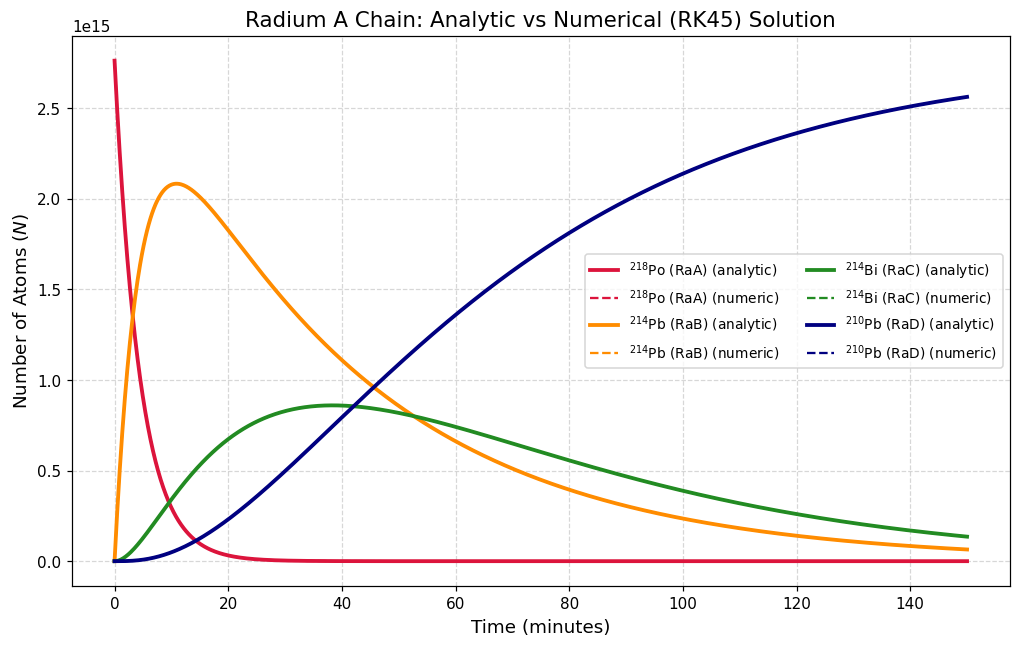

In [ ]:
# Re-use the RaA chain already defined above (lamda, N1_0, num_members, t, N_t, a)
N0_vec = np.zeros(num_members)
N0_vec[0] = N1_0

N_numeric = numeric_solve(lamda, N0_vec, t, num_members)

# --- Comparison plot: analytic (solid) vs numeric (dashed) ---
plt.figure(figsize=(11, 6.5))
colors = ["crimson", "darkorange", "forestgreen", "navy"]
labels = [r"$^{218}$Po (RaA)", r"$^{214}$Pb (RaB)", r"$^{214}$Bi (RaC)", r"$^{210}$Pb (RaD)"]

for k in range(1, num_members + 1):
    plt.plot(t_minutes, N_t[k], color=colors[k-1], lw=2.5, label=f"{labels[k-1]} (analytic)")
    plt.plot(t_minutes, N_numeric[k-1], color=colors[k-1], lw=1.5, ls="--",
              label=f"{labels[k-1]} (numeric)")

plt.title("Radium A Chain: Analytic vs Numerical (RK45) Solution", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Number of Atoms ($N$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9, ncol=2, loc="right")
plt.gca().ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
plt.show()

print("Validation: analytic vs numeric max relative differences")
for k in range(1, num_members + 1):
    diff = np.abs(N_t[k] - N_numeric[k - 1])
    rel = diff / (np.abs(N_t[k]).max() + 1e-30)
    print(f"  N_{k}: max |analytic - numeric| = {diff.max():.3e}, "
          f"max relative diff = {rel.max():.2e}")


The analytic and numerical curves overlap almost perfectly (dashed vs. solid), and the maximum relative difference between the two methods is of order $10^{-11}$&ndash;$10^{-12}$ for every member of the chain &mdash; essentially floating-point precision. This confirms both that the Bateman coefficients derived earlier are correct, and that the numerical integrator is set up correctly.

## Step 2 &mdash; A custom decay chain with our own half-lives (5 nuclei)

Now we try a chain we made up ourselves: **5 members** (one more than the RaA case) with half-lives that are *not* physical isotopes, deliberately mixing a very fast step ($T_{1/2}=5$), a very slow step ($T_{1/2}=90$), and everything in between, so that the chain visibly has several competing timescales.

Half-lives used: [12.0, 45.0, 5.0, 90.0, 30.0]
Decay constants (lambda): ['0.0578', '0.0154', '0.1386', '0.0077', '0.0231']

Validation: analytic vs numeric max relative differences
  N_1: max |analytic - numeric| = 1.546e-08, max relative diff = 3.09e-11
  N_2: max |analytic - numeric| = 2.093e-08, max relative diff = 6.77e-11
  N_3: max |analytic - numeric| = 9.272e-09, max relative diff = 2.78e-10
  N_4: max |analytic - numeric| = 1.002e-08, max relative diff = 4.11e-11
  N_5: max |analytic - numeric| = 1.451e-09, max relative diff = 1.99e-11

Conservation check (numeric): min=160.141053, max=500.000000, expected=500.0


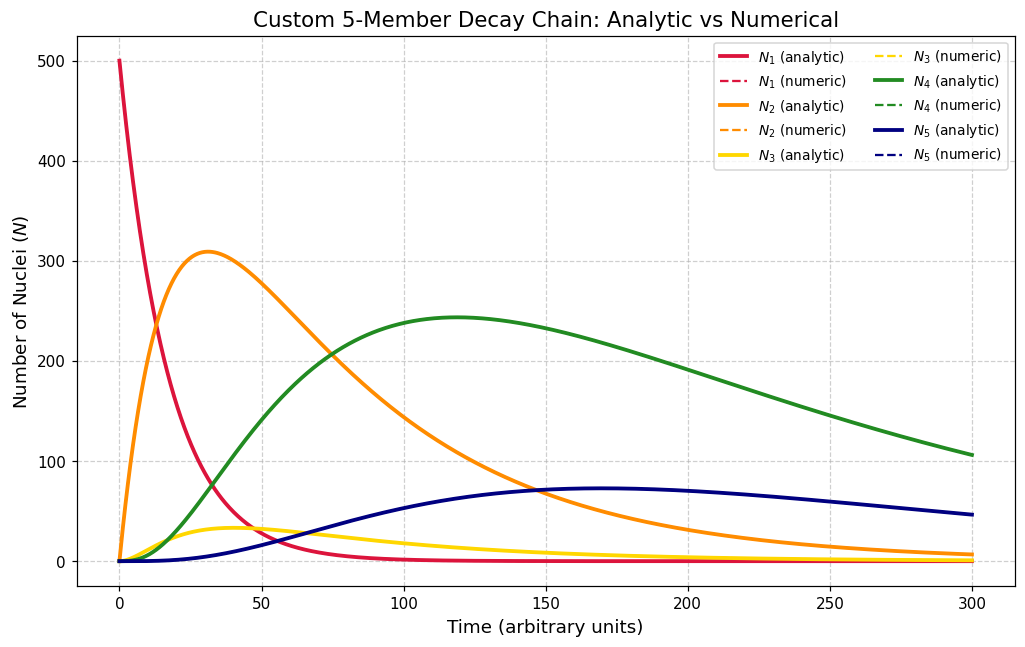

In [ ]:
# --- Our own custom decay chain: 5 members, half-lives chosen by us (arbitrary units) ---
num_members_custom = 5
half_lives_custom = [12.0, 45.0, 5.0, 90.0, 30.0]   # deliberately mixes fast & slow steps
lamda_custom = [0] + [np.log(2) / T for T in half_lives_custom]
N1_0_custom = 500.0

# Analytic solution (Bateman coefficients)
a_custom = analytic_bateman_coeffs(lamda_custom, N1_0_custom, num_members_custom)
t_custom = np.linspace(0, 300, 1000)
N_an_custom = analytic_evaluate(a_custom, lamda_custom, t_custom, num_members_custom)

# Numerical solution (RK45 on dN/dt = A N)
N0_vec_custom = np.zeros(num_members_custom)
N0_vec_custom[0] = N1_0_custom
N_num_custom = numeric_solve(lamda_custom, N0_vec_custom, t_custom, num_members_custom)

plt.figure(figsize=(11, 6.5))
colors5 = ["crimson", "darkorange", "gold", "forestgreen", "navy"]
for k in range(1, num_members_custom + 1):
    plt.plot(t_custom, N_an_custom[k], color=colors5[k-1], lw=2.5,
              label=f"$N_{k}$ (analytic)")
    plt.plot(t_custom, N_num_custom[k-1], color=colors5[k-1], lw=1.5, ls="--",
              label=f"$N_{k}$ (numeric)")

plt.title("Custom 5-Member Decay Chain: Analytic vs Numerical", fontsize=14)
plt.xlabel("Time (arbitrary units)", fontsize=12)
plt.ylabel("Number of Nuclei ($N$)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=9, ncol=2)
plt.show()

print(f"Half-lives used: {half_lives_custom}")
print(f"Decay constants (lambda): {[f'{l:.4f}' for l in lamda_custom[1:]]}")
print()
print("Validation: analytic vs numeric max relative differences")
for k in range(1, num_members_custom + 1):
    diff = np.abs(N_an_custom[k] - N_num_custom[k - 1])
    rel = diff / (np.abs(N_an_custom[k]).max() + 1e-30)
    print(f"  N_{k}: max |analytic - numeric| = {diff.max():.3e}, "
          f"max relative diff = {rel.max():.2e}")

# Conservation-of-nuclei check (sum of all members must equal N1_0 at all times)
total_numeric = N_num_custom.sum(axis=0)
print()
print(f"Conservation check (numeric): min={total_numeric.min():.6f}, "
      f"max={total_numeric.max():.6f}, expected={N1_0_custom}")


Again the analytic and numerical solutions agree to numerical precision, and the conservation check confirms the total number of nuclei summed over all 5 members stays equal to $N_1(0)=500$ at every timestep (up to the small amount that has not yet reached member 5 within the simulated time window). This is a nice, quick generalization: because `analytic_bateman_coeffs`, `build_decay_matrix`, and `numeric_solve` were written to take `num_members` as a parameter, we did not have to change any of the underlying logic to go from 4 to 5 members &mdash; only the `half_lives_custom` list changed.